In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/WELFake_Dataset.csv')

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [ ]:
df = df.dropna()

In [ ]:
df['content'] = df['title'] + " " + df['text']
df = df[['content', 'label']]

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

df['content'] = df['content'].apply(clean_text)

In [ ]:
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=500)
X_test_pad = pad_sequences(X_test_seq, maxlen=500)

In [ ]:
model = Sequential()
model.add(Embedding(10000, 128))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 560s 346ms/step - accuracy: 0.8869 - loss: 0.2763 - val_accuracy: 0.9327 - val_loss: 0.1862
Epoch 2/5
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 561s 348ms/step - accuracy: 0.8905 - loss: 0.2593 - val_accuracy: 0.8401 - val_loss: 0.3444
Epoch 3/5
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 556s 346ms/step - accuracy: 0.9074 - loss: 0.2232 - val_accuracy: 0.9497 - val_loss: 0.1365
Epoch 4/5
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 565s 347ms/step - accuracy: 0.9663 - loss: 0.0978 - val_accuracy: 0.9596 - val_loss: 0.1085
Epoch 5/5
1610/1610 ━━━━━━━━━━━━━━━━━━━━ 565s 349ms/step - accuracy: 0.9820 - loss: 0.0569 - val_accuracy: 0.9685 - val_loss: 0.1073


In [ ]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

448/448 ━━━━━━━━━━━━━━━━━━━━ 42s 93ms/step - accuracy: 0.9655 - loss: 0.1099
Test Accuracy: 0.9655437469482422


In [ ]:
y_pred = model.predict(X_test_pad)
y_pred = (y_pred > 0.5)

448/448 ━━━━━━━━━━━━━━━━━━━━ 37s 81ms/step


In [ ]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97      7081
           1       0.96      0.97      0.97      7227

    accuracy                           0.97     14308
   macro avg       0.97      0.97      0.97     14308
weighted avg       0.97      0.97      0.97     14308

[[6820  261]
 [ 232 6995]]


In [ ]:
lstm_acc = accuracy
lstm_prec = precision_score(y_test, y_pred)
lstm_rec = recall_score(y_test, y_pred)
lstm_f1 = f1_score(y_test, y_pred)

print("Accuracy:", lstm_acc)
print("Precision:", lstm_prec)
print("Recall:", lstm_rec)
print("F1 Score:", lstm_f1)

Accuracy: 0.9655437469482422
Precision: 0.9640297684674752
Recall: 0.9678981596789816
F1 Score: 0.9659600911413381


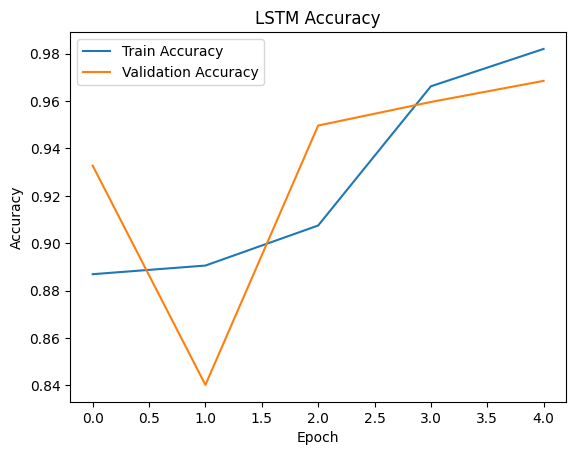

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

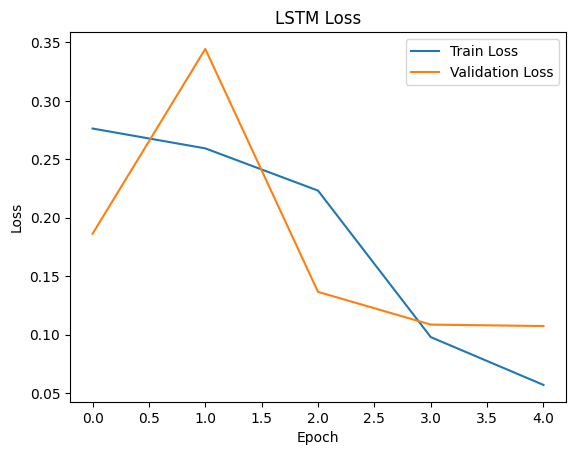

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()